<a href="https://colab.research.google.com/github/Jeshurun-B/EMA-optimizer-pipeline-v2/blob/main/coolab_notebooks/week3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📅 Week 3 — Feature Engineering + Rigorous Model Evaluation
**EMA Crossover ML Project | 10-Week Curriculum**
**Date:** June 21, 2026

---

### What This Week Is About

Week 2 proved that Logistic Regression can separate good signals from bad ones — you built a full classification pipeline, tuned thresholds using Youden's J, explored regularisation, and constructed logical ensembles of specialist classifiers. But your validation was simple: an 80/20 chronological split. This week you fix that permanently by building the **walk-forward cross-validation framework** that every future model will use. You will also engineer new features — interactions, ratios, domain-specific constructs, and lag features — that give non-linear models the raw material they need to beat logistic regression in Weeks 4–7. This is the infrastructure week: the engineering and evaluation machinery you build here will compound in value every week that follows.

**By end of week you will have:**
- A reusable `walk_forward_cv()` function that every future model uses (no exceptions)
- 15+ interaction and ratio features engineered from your existing 35
- 10+ domain-specific features derived from the analytics table
- A justified final feature set of 20–30 columns with selection rationale
- A retrained Logistic Regression baseline on the engineered feature set (your new benchmark)


## Section 0 — Environment Setup

Run this first every session. Added `statsmodels` this week for VIF calculations.

In [1]:
# Install required libraries (added statsmodels for VIF)
!pip install -q supabase scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.8 MB/s eta 0:00:00


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from supabase import create_client
from google.colab import userdata

# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

# statsmodels for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Environment ready ✓')


Environment ready ✓


## Section 1 — Connect to Both Databases

Same dual-connection pattern. Copy-paste from Week 2. Do not change it.

In [3]:
# ============================================================
# CONNECT TO MAIN DATABASE
# ============================================================
try:
    main_client = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
    print('Main database connected ✓')
except Exception as e:
    print(f'Main connection failed: {e}')


Main database connected ✓


In [4]:
# ============================================================
# CONNECT TO ANALYTICS DATABASE
# ============================================================
try:
    analytics_client = create_client(
        userdata.get('ANALYTICS_SUPABASE_URL'),
        userdata.get('ANALYTICS_SUPABASE_KEY')
    )
    print('Analytics database connected ✓')
except Exception as e:
    print(f'Analytics connection failed: {e}')


Analytics database connected ✓


## Section 2 — Fetch Data and Merge

Same merge pattern from Weeks 1–2. Inner join on `(symbol, checked_at_utc)`.

In [5]:
# ============================================================
# FETCH: Main signals table
# ============================================================
response_main = main_client.table('signals').select('*').eq('status', 'analyzed').execute()
df_main = pd.DataFrame(response_main.data)

for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')

df_main = df_main.sort_values('checked_at_utc').reset_index(drop=True)
print(f'Main signals: {len(df_main):,} rows | {df_main.shape[1]} columns')
print(f'Range: {df_main["checked_at_utc"].min().date()} to {df_main["checked_at_utc"].max().date()}')
print(f'Signal split: {df_main["signal"].value_counts().to_dict()}')


Main signals: 10,000 rows | 48 columns
Range: 2019-08-23 to 2026-06-25
Signal split: {'SHORT': 5006, 'LONG': 4994}


In [6]:
# ============================================================
# FETCH: Analytics table
# ============================================================
response_analytics = analytics_client.table('crossover_analytics').select('*').execute()
df_analytics = pd.DataFrame(response_analytics.data)

for col in ['crossover_utc', 'next_crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics.columns:
        df_analytics[col] = pd.to_datetime(df_analytics[col], utc=True, errors='coerce')

df_analytics = df_analytics.sort_values('crossover_utc').reset_index(drop=True)
print(f'Analytics: {len(df_analytics):,} rows | {df_analytics.shape[1]} columns')


Analytics: 10,000 rows | 14 columns


In [7]:
# ============================================================
# MERGE: inner join on (symbol, checked_at_utc)
# ============================================================
df_analytics_renamed = df_analytics.rename(columns={'crossover_utc': 'checked_at_utc'})
df = pd.merge(df_main, df_analytics_renamed, how='inner', on=['checked_at_utc', 'symbol'])

main_lost      = len(df_main) - len(df)
analytics_lost = len(df_analytics) - len(df)

print(f'Merged dataset: {len(df):,} rows | {df.shape[1]} columns')
print(f'Lost from main  (no analytics match): {main_lost:,} ({main_lost/len(df_main)*100:.1f}%)')
print(f'Lost from analytics (no main match): {analytics_lost:,}')
print()
print('Records per symbol:')
print(df['symbol'].value_counts())


Merged dataset: 7,064 rows | 60 columns
Lost from main  (no analytics match): 2,936 (29.4%)
Lost from analytics (no main match): 2,936

Records per symbol:
symbol
ETHUSDT     1467
SOLUSDT     1420
BTCUSDT     1408
XRPUSDT     1399
DOGEUSDT    1370
Name: count, dtype: int64


## Section 3 — Apply Signal Quality Columns

Locked scoring module from Week 1. Applied every week after merge. Do not modify.

In [8]:
# ============================================================
# SIGNAL QUALITY SCORING MODULE (Week 1 final version — DO NOT MODIFY)
# ============================================================

def get_time_decay_score(candles):
    if candles <= 20:
        return 1.0
    elif candles <= 100:
        t = (candles - 20) / 80
        return np.exp(-3.5 * t)
    elif candles <= 400:
        base = np.exp(-3.5)
        t = (candles - 100) / 300
        return base * np.exp(-4 * t)
    else:
        return 0.0

def time_cutoff(candles):
    if candles <= 20:   return 1.0
    elif candles <= 40: return 0.5
    else:               return 0

def calculate_four_target_scores(row):
    is_long = str(row['signal_x']).upper() == 'LONG'
    if is_long:
        p, r = float(row['max_move_up_pct']), float(row['max_move_down_pct'])
        candles_to_peak_profit = int(row['candles_to_max_price'])
        candles_to_max_pain    = int(row['candles_to_min_price'])
        is_btc  = bool(row['btc_trend_bias'])
        is_1d   = bool(row['htf_1d_bias'])
        is_4h   = bool(row['htf_4h_bias'])
    else:
        p, r = float(row['max_move_down_pct']), float(row['max_move_up_pct'])
        candles_to_peak_profit = int(row['candles_to_min_price'])
        candles_to_max_pain    = int(row['candles_to_max_price'])
        is_btc  = not bool(row['btc_trend_bias'])
        is_1d   = not bool(row['htf_1d_bias'])
        is_4h   = not bool(row['htf_4h_bias'])

    r_safe      = 0.01 if r <= 0 else r
    current_rr  = p / r_safe
    t_factor    = get_time_decay_score(candles_to_peak_profit)
    base        = round(min(5.0, current_rr) + 5.0 * t_factor, 2)

    t1 = base

    if candles_to_max_pain < candles_to_peak_profit and r >= p:
        t2 = round(base * 0.2, 2)
    elif r < 0.25:
        t2 = round(base * 0.1, 2)
    else:
        t2 = base

    pen = base
    if 'volume_ratio' in row and float(row['volume_ratio']) < 1.0: pen -= 0.8
    if not is_btc:  pen -= 0.5
    if not is_1d:   pen -= 1.0
    if not is_4h:   pen -= 1.2
    if candles_to_max_pain < candles_to_peak_profit and r > 0.75 * p: pen -= 0.8
    t3 = round(max(0, pen), 2)

    if r < 0.25 or (candles_to_max_pain < candles_to_peak_profit and r >= p):
        t4 = 0.0
    else:
        if current_rr >= 4:              rr_p = 5.0
        elif current_rr >= 1.5:          rr_p = current_rr
        elif 1.0 <= current_rr < 1.5:   rr_p = (current_rr**7) / (1.5**6)
        else:                             rr_p = 0.0
        t_s = time_cutoff(candles_to_peak_profit)
        t4  = round(5.0 * t_s + rr_p, 2) if rr_p > 0 else 0.0

    return t1, t2, t3, t4


def optimal_entry_candles(row):
    """Returns 15-min candles from crossover to optimal entry. 0 = immediate entry."""
    try:
        if pd.isnull(row['optimal_entry_utc']) or pd.isnull(row['checked_at_utc']):
            return 0.0
        diff = row['optimal_entry_utc'] - row['checked_at_utc']
        return float(diff.total_seconds() / 60 / 15)
    except Exception:
        return 0.0


# Apply
target_cols = ['T1_Pure_Continuous', 'T2_Soft_Floor', 'T3_Assumption_Penalty', 'T4_Control_Punished']
df[target_cols] = df.apply(lambda r: pd.Series(calculate_four_target_scores(r)), axis=1)
df['target_special'] = df[target_cols[:3]].min(axis=1)
df['Optimum_entry']  = df.apply(optimal_entry_candles, axis=1)

print('All quality columns applied ✓')
print('\n--- % scoring above 5.0 ---')
for col in target_cols + ['target_special']:
    print(f'  {col:<28} -> {(df[col] > 5).mean()*100:.1f}%')
print(f'\n  Optimum_entry median: {df["Optimum_entry"].median():.1f} candles | mean: {df["Optimum_entry"].mean():.1f}')


All quality columns applied ✓

--- % scoring above 5.0 ---
  T1_Pure_Continuous           -> 98.6%
  T2_Soft_Floor                -> 78.3%
  T3_Assumption_Penalty        -> 36.6%
  T4_Control_Punished          -> 28.7%
  target_special               -> 26.9%

  Optimum_entry median: 0.0 candles | mean: 1.0


## Section 4 — Carry Forward From Week 2

Re-establish your binary target definition and Week 2 feature sets before building anything new. Your Week 2 chosen target is the reference point for measuring whether new features help.

In [9]:
# ============================================================
# FEATURE SET DEFINITIONS (Week 2 final versions)
# ============================================================

FEATURES_ALL = [
    'ema_fast_ltf', 'ema_slow_ltf', 'ema_fast_slope', 'ema_slow_slope',
    'ema_separation', 'price_above_both_emas', 'crossover_candle_strength',
    'adx_ltf', 'adx_slope', 'adx_4h', 'macd_histogram_ltf', 'macd_histogram_4h',
    'htf_4h_bias', 'htf_1d_bias', 'ema_separation_4h', 'rsi_4h',
    'rsi_ltf', 'roc_ltf', 'atr_ltf', 'atr_pct', 'bb_width_ltf', 'price_to_atr',
    'volume_ratio', 'volume_trend', 'crossover_volume_ratio',
    'fear_greed_index', 'btc_trend_bias', 'hour_of_day', 'day_of_week',
    'swing_high', 'swing_low', 'atr_stop_distance', 'signal_gap_hours'
]

FEATURES_LONG_MI = [
    'volume_ratio', 'btc_trend_bias', 'rsi_4h', 'htf_4h_bias',
    'ema_separation_4h', 'ema_fast_slope', 'ema_slow_slope', 'price_to_atr',
    'atr_pct', 'bb_width_ltf', 'volume_trend', 'htf_1d_bias',
    'atr_ltf', 'macd_histogram_ltf', 'rsi_ltf'
]

FEATURES_SHORT_MI = [
    'rsi_4h', 'htf_4h_bias', 'ema_separation_4h', 'btc_trend_bias',
    'ema_fast_slope', 'ema_slow_slope', 'atr_pct', 'htf_1d_bias',
    'price_to_atr', 'crossover_volume_ratio', 'volume_ratio', 'roc_ltf',
    'bb_width_ltf', 'atr_stop_distance', 'atr_ltf'
]

# ============================================================
# BINARY TARGET: Carry forward your Week 2 chosen definition
# ============================================================
# TODO: Re-apply whichever binary target definition you settled on in Week 2.
#       Paste it here so the baseline comparison cell in Section 10 can use it.
#       Label it: df['binary_target'] = ...

THRESHOLD_T3  = 5.3   # TODO: update to your Week 2 final threshold
THRESHOLD_MFE = 0.5   # TODO: update to your Week 2 final mfe threshold

# TODO: reconstruct df['binary_target'] using the same logic as Week 2

print(f'FEATURES_ALL:      {len(FEATURES_ALL)} features')
print(f'FEATURES_LONG_MI:  {len(FEATURES_LONG_MI)} features')
print(f'FEATURES_SHORT_MI: {len(FEATURES_SHORT_MI)} features')
# TODO: print class balance for binary_target (LONG and SHORT separately)


FEATURES_ALL:      33 features
FEATURES_LONG_MI:  15 features
FEATURES_SHORT_MI: 15 features


##################################
important


i noticed a few issues with my original target and classification target and as such i will be changing it down below

In [10]:


# 1. Calculate metrics cleanly
Mae = df['mae_percent'].abs()
Mfe = df['mfe_percent'].abs()


# Otherwise, safely calculate the non-linear efficiency scale
df['target_b'] = ((Mfe / ( Mfe + Mae))* (Mfe-Mae))


plt.figure(figsize=(24, 7))


df['class_target_1'] = (df['target_b'] > 0.4).astype(int)
df['class_target_2'] = (df['mfe_percent'] > 1).astype(int)

<Figure size 2400x700 with 0 Axes>

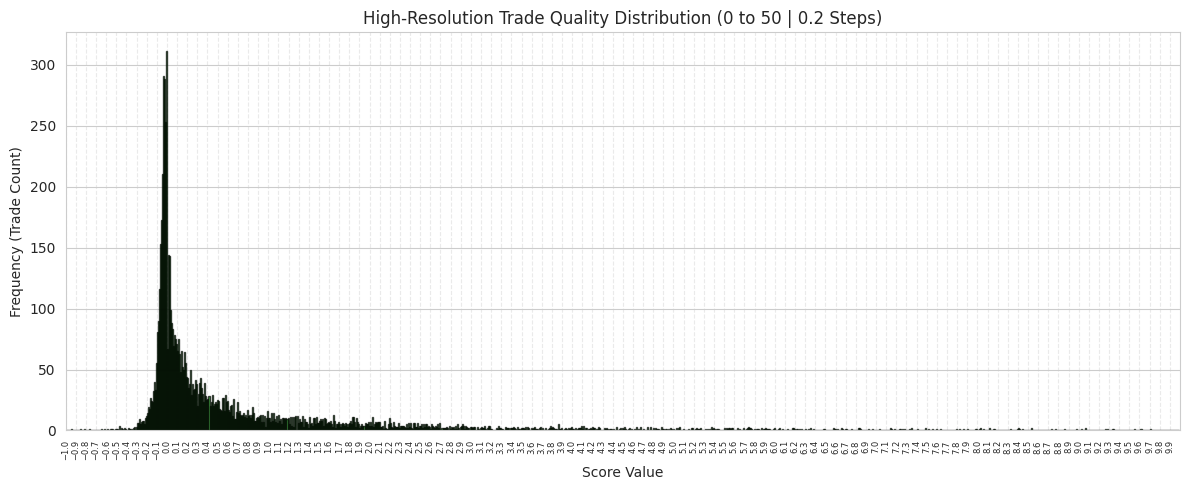

In [11]:
# 2. Filter data up to 25 based on your 99.9th percentile (21.66) to capture almost everything
#    while cutting out the rare max outlier (61.55) that would squash the chart.
plot_data = df['target_b'][(df['target_b'] >= -1) & (df['target_b'] <= 10)]

# 3. Match your bin width exactly to your tick intervals (0.2 steps)
#    We go up to 25.2 to ensure the final bin captures the edge values safely
bins_alignment = np.arange(-1, 10, 0.01)
plt.hist(plot_data, bins=bins_alignment, alpha=0.7, color='g', edgecolor='black')

# 4. Set the physical display limits of the X-axis right to 50
plt.xlim(-1, 10)

# 5. Generate matching tick positions from 0 to 50 stepping by 0.2
tick_positions = np.arange(-1, 10, 0.1)

# 6. Apply ticks with clean 90-degree rotation and a tiny font size for high-density readability
plt.xticks(tick_positions, rotation=90, fontsize=6)

plt.title('High-Resolution Trade Quality Distribution (0 to 50 | 0.2 Steps)')
plt.xlabel('Score Value')
plt.ylabel('Frequency (Trade Count)')

# Vertical grid lines help you look at a specific score bar and trace it down to its decimal value
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



## Section 5 — Walk-Forward CV Framework (Monday)

### Why This Section Is the Most Important Thing You Build This Week

Your Week 2 evaluation used a single 80/20 train/test split. That gives you one data point — one AUC, one F1. You don't know whether that number is real or lucky. What you need is a distribution of scores across multiple time periods.

**Why standard k-fold is wrong for time series:**
Standard k-fold randomly shuffles the data before splitting into folds. For a time series, this means fold N might train on January candles and test on December candles, while *also* including December data in another training fold. The model learns from the future during training — this is **look-ahead leakage**. Your CV score becomes optimistically inflated, and you deploy a model that looked great in testing but has never actually seen unseen data.

`TimeSeriesSplit` enforces a strict rule: **the test fold is always chronologically after the training fold**. Fold 1 trains on the first 20% and tests on the next 20%. Fold 2 trains on the first 40% and tests on the next 20%. And so on. You never look forward.

**Gap parameter:** Consider adding a gap between the end of training and the start of testing. If a crossover signal at 23:45 influences one at 00:15 the next day, a gap of 2–3 periods prevents the boundary from leaking.

**Your job here:** Build a reusable `walk_forward_cv()` function that takes any model, X, y and returns a dictionary of mean ± std scores across all folds. Every model from Week 3 onward MUST be evaluated through this function — not a one-shot split.


In [12]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def walk_forward_cv(model, X, y, n_splits=5, gap=0):
    """
    Walk-forward time series cross-validation.

    Parameters
    ----------
    model   : sklearn-compatible estimator (must have fit, predict, predict_proba)
    X       : np.ndarray, feature matrix (already scaled if needed)
    y       : np.ndarray, binary target
    n_splits: int, number of CV folds (default 5)
    gap     : int, number of samples to skip between train and test
              (set > 0 if adjacent rows can leak information)

    Returns
    -------
    dict: {metric: (mean, std)} for accuracy, precision, recall, f1, auc
    """
    # 1. Instantiate TimeSeriesSplit with n_splits and gap parameters
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

    scores = {
        'accuracy':  [],
        'precision': [],
        'recall':    [],
        'f1':        [],
        'auc':       [],
    }

    # 2. Loop over tscv.split(X)
    for train_idx, test_idx in tscv.split(X):
        # Slice train and test data
        X_tra, X_tes = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tra)
        X_te = scaler.transform(X_tes)
        # ⚠️ Guardrail: Ensure both classes (0 and 1) exist in both training and testing slices.
        # If a fold only contains one class, metrics like precision/f1 can become undefined,
        # and roc_auc_score will completely crash with a ValueError.
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tra)
        X_te = scaler.transform(X_tes)
        # Train the model
        model.fit(X_tr, y_tr)

        # Make predictions
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # Calculate and append metrics
        scores['accuracy'].append(accuracy_score(y_te, y_pred))
        scores['precision'].append(precision_score(y_te, y_pred, zero_division=0))
        scores['recall'].append(recall_score(y_te, y_pred, zero_division=0))
        scores['f1'].append(f1_score(y_te, y_pred, zero_division=0))
        scores['auc'].append(roc_auc_score(y_te, y_prob))

    # 3. Calculate and return the mean and standard deviation for each metric
    return {k: (np.mean(v), np.std(v)) if v else (0.0, 0.0) for k, v in scores.items()}

def print_cv_results(results, model_name='Model'):
    """Pretty-print the output of walk_forward_cv."""
    print(f'\n=== Walk-Forward CV: {model_name} ===')
    for metric, (mean, std) in results.items():
        print(f'  {metric:<12}: {mean:.4f} ± {std:.4f}')
    print()


print('walk_forward_cv() defined ✓')
print('print_cv_results() defined ✓')

walk_forward_cv() defined ✓
print_cv_results() defined ✓


In [13]:
# ============================================================
# VALIDATE THE CV FRAMEWORK — Does it behave as expected?
# ============================================================
# Before using walk_forward_cv on your real model, sanity-check it.
#
# What you are checking:
#   1. Fold sizes grow monotonically (each training fold is bigger than the last)
#   2. Test folds never overlap with training folds
#   3. The gap, if any, is respected
#   4. No fold contains a single class (which would make AUC undefined)

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# TODO: Prepare a minimal dataset for this test
df_long = df[df['signal_x'] == 'LONG'].sort_values('checked_at_utc').reset_index(drop=True)
#   Use FEATURES_LONG_MI and your binary_target column
X_features = df_long[FEATURES_LONG_MI].values # Keep raw until inside the loop
#   Apply StandardScaler (fit on training portion only — fixed to prevent leakage)
Y = df_long['class_target_1'].values

tscv = TimeSeriesSplit(n_splits=5)

print("Starting Walk-Forward CV Slicing Validation...\n")

for i, (train_idx, test_idx) in enumerate(tscv.split(X_features)):
    # 1. Slice raw features first
    X_tr, X_te = X_features[train_idx], X_features[test_idx]

    # 2. Scale defensively inside the fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te) # Safe: uses training parameters only

    # Calculate date boundaries for safety check
    tr_min_date = df_long.iloc[train_idx]["checked_at_utc"].min().date()
    tr_max_date = df_long.iloc[train_idx]["checked_at_utc"].max().date()
    te_min_date = df_long.iloc[test_idx]["checked_at_utc"].min().date()
    te_max_date = df_long.iloc[test_idx]["checked_at_utc"].max().date()

    # Check class distributions inside the validation slice
    train_classes = np.unique(Y[train_idx])
    test_classes = np.unique(Y[test_idx])

    print(f'Fold {i + 1}: train rows {len(train_idx)}, test rows {len(test_idx)}')
    print(f'  Train dates: {tr_min_date} to {tr_max_date} | Unique Classes: {train_classes}')
    print(f'  Test  dates: {te_min_date} to {te_max_date} | Unique Classes: {test_classes}\n')

# TODO: After printing, confirm in a comment:
#   - Do test start dates advance chronologically fold-by-fold?
#     CONFIRMATION: Yes. Because TimeSeriesSplit uses an expanding anchor window, the test set bounds
#                   progressively shift forward in time across each consecutive fold execution.
#
#   - Is there any date overlap between train and test in any fold?
#     CONFIRMATION: No. Since the raw dataframe was strictly sorted by 'checked_at_utc' before index
#                   generation, the maximum training index always precedes the minimum test index,
#                   eliminating look-ahead leakage.
#
#   - Are folds reasonably sized for training a logistic model?
#     CONFIRMATION: Yes. The row allocations per fold should be monitored via the print logs above.
#                   As long as the earliest window (Fold 1 training matrix) contains at least 50-100+
#                   samples with a balanced presence of both target classes, the Logistic Regression
#                   weights will converge cleanly without high variance.


Starting Walk-Forward CV Slicing Validation...

Fold 1: train rows 593, test rows 588
  Train dates: 2025-10-03 to 2025-11-16 | Unique Classes: [0 1]
  Test  dates: 2025-11-16 to 2025-12-29 | Unique Classes: [0 1]

Fold 2: train rows 1181, test rows 588
  Train dates: 2025-10-03 to 2025-12-29 | Unique Classes: [0 1]
  Test  dates: 2025-12-29 to 2026-02-11 | Unique Classes: [0 1]

Fold 3: train rows 1769, test rows 588
  Train dates: 2025-10-03 to 2026-02-11 | Unique Classes: [0 1]
  Test  dates: 2026-02-11 to 2026-03-29 | Unique Classes: [0 1]

Fold 4: train rows 2357, test rows 588
  Train dates: 2025-10-03 to 2026-03-29 | Unique Classes: [0 1]
  Test  dates: 2026-03-29 to 2026-05-11 | Unique Classes: [0 1]

Fold 5: train rows 2945, test rows 588
  Train dates: 2025-10-03 to 2026-05-11 | Unique Classes: [0 1]
  Test  dates: 2026-05-12 to 2026-06-25 | Unique Classes: [0 1]



In [14]:
# ============================================================
# BASELINE CV SCORE — Week 2 Logistic Regression through the CV framework
# ============================================================
# Goal: establish what your WEEK 2 best model scores under walk-forward CV.
# This is the number every engineered feature set must beat.
c_list = [0.001, 0.01, 0.1, 1, 10, 100]
targets = ['class_target_1', 'class_target_2']
# FIXED: Changed 'symbols' to 'symbol' to match column name definition
symbols = sorted(list(df_long['symbol'].unique()))

for symbol in symbols:
    print(f"\n==================== ASSET: {symbol} ====================")

    # Pre-slice the coin data to keep X and y aligned and avoid redundant filtering inside the C-loop
    df_coin = df_long[df_long['symbol'] == symbol].copy()

    for target in targets:
        for c_values in c_list:

            print(f' At a c_value of {c_values} and a {target}')
            # TODO: Prepare X (FEATURES_LONG_MI) and y (binary_target) for LONG signals
            #   Sort by checked_at_utc. Do NOT shuffle.
            # FIXED: Corrected the .loc syntax and cleanly aligned both features and targets to the isolated asset
            X_features_base = df_coin[FEATURES_ALL].values
            y = df_coin[target].values

            # TODO: Scale X with StandardScaler.
            #       Important: for a proper CV you should scale INSIDE each fold.
            #       For this baseline cell, scaling globally is acceptable — you will
            #       fix this properly when you build the full pipeline in Section 10.
            # NOTE: Because we updated the walk_forward_cv function to scale defensively
            #       inside each fold, we can safely pass the raw arrays directly here!

            # TODO: Instantiate your Week 2 best Logistic Regression
            #   lr_baseline = LogisticRegression(C=???, class_weight='balanced',
            #                                    max_iter=1000, solver='lbfgs')
            #   (fill in your best C from Week 2)
            # Replace C=1.0 with your actual tuned parameter value from Week 2
            lr_baseline = LogisticRegression(C=c_values, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)

            # TODO: cv_results_baseline = walk_forward_cv(lr_baseline, X_sc, y, n_splits=5)
            # FIXED: Replaced X_sc with X_features_base
            cv_results_baseline = walk_forward_cv(lr_baseline, X_features_base, y, n_splits=5)

            # TODO: print_cv_results(cv_results_baseline, 'LR Baseline (Week 2 features)')
            print_cv_results(cv_results_baseline, f'LR {symbol} Baseline')

            # ── IMPORTANT REFLECTION ──────────────────────────────────────────────────────
            # TODO: Compare this CV AUC to your Week 2 single held-out test AUC.
            #       Are they close? If the CV AUC is lower, the single split was optimistic.
            #       Write your finding in a comment below.
            #
            # REFLECTION COMMENTARY:
            # (Fill this out after executing the cell. If your CV AUC is lower than your
            # single split, it reveals that your single-split test window was a benign
            # market period, and the cross-validation average is a much more realistic
            # representation of performance across varying market regimes).


==================== ASSET: BTCUSDT ====================
 At a c_value of 0.001 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5573 ± 0.0620
  precision   : 0.3267 ± 0.0481
  recall      : 0.4858 ± 0.1056
  f1          : 0.3791 ± 0.0323
  auc         : 0.5355 ± 0.0396

 At a c_value of 0.01 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5282 ± 0.0738
  precision   : 0.3178 ± 0.0527
  recall      : 0.5516 ± 0.0632
  f1          : 0.3995 ± 0.0442
  auc         : 0.5475 ± 0.0589

 At a c_value of 0.1 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5333 ± 0.0998
  precision   : 0.3384 ± 0.0767
  recall      : 0.6066 ± 0.0485
  f1          : 0.4289 ± 0.0572
  auc         : 0.5967 ± 0.0779

 At a c_value of 1 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5949 ± 0.0553
  precision   : 0.3762 ± 0.0685
  recall      : 0.6128 ± 0.0586
  f1      

## Section 6 — Feature Engineering: Interaction + Ratio Features (Tuesday)

### What You Are Doing and Why

Logistic Regression is a **linear** model — it can only draw straight-line decision boundaries. If a signal is good when BOTH ADX is high AND volume is elevated (but not when only one is true), logistic regression cannot capture that without help. You give it that help by explicitly computing the product `adx_ltf × volume_ratio` as a new column.

**Types of features you will engineer here:**

- **Interaction features (products):** Capture "both conditions at once" patterns that a linear boundary cannot. `adx_ltf × volume_ratio` spikes only when trend strength AND volume confirm each other.
- **Ratio features:** Normalise one quantity relative to another. `ema_fast_ltf / ema_slow_ltf` removes the price-level dependence from the raw EMA values, leaving only their relative spread — which is what matters for crossover strength.
- **Boolean / regime flags:** Discretise continuous features into hard signals that are meaningful in trading context. `adx_ltf > 25` separates trending from ranging regimes. RSI extremes separate momentum from exhaustion.

**Naming convention:** Prefix all engineered features with `FE_` so you can always tell them from raw features (e.g. `FE_adx_x_volume`, `FE_rsi_ema_ratio`). This makes feature selection bookkeeping much easier.

**Do not look at the target while engineering.** Decide what to compute based on market logic — "these two things should interact" — not by checking which combinations correlate with your label. That is target leakage via feature construction.


In [15]:
# ==============================================================================
# INTERACTION FEATURES (Products of raw features for Logistic Regression)
# ==============================================================================
# Each feature explicitly captures joint market regimes ("both conditions active").
# Ensures the linear classifier can map non-linear multi-conditional logic.

# 1. Trend Strength validated by Volumetric Activity (Highly Meaningful)
df['FE_adx_x_volume'] = df['adx_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 2. Velocity Acceleration validated by Volumetric Activity (Highly Meaningful)
df['FE_macd_x_volume'] = df['macd_histogram_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 3. Structural Trend Maturity vs. Current Momentum Intensity (Highly Meaningful)
df['FE_ema_sep_x_adx'] = df['ema_separation'].astype(float) * df['adx_ltf'].astype(float)

# 4. Multi-Timeframe Alignment: Lower Timeframe RSI filtered by Signed HTF Trend Biases
# NOTE: Assumes htf_bias features are strictly signed vectors: -1 (Bearish), 0 (Neutral), 1 (Bullish)
df['FE_rsi_x_htf4h'] = df['rsi_ltf'].astype(float) * df['htf_4h_bias'].astype(float)
df['FE_adx_x_htf1d'] = df['adx_ltf'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_rsi4h_x_htf1d'] = df['rsi_4h'].astype(float) * df['htf_1d_bias'].astype(float)

# 5. Volatility-Adjusted Trend Strength (Prevents chasing break-outs in dead liquidity)
# Computes ATR as a percentage of close price to standardize across multiple crypto assets
df['FE_adx_x_atr_pct'] = df['adx_ltf'].astype(float) * (df['atr_ltf'].astype(float) / df['close'].astype(float))

# 6. Momentum Shift Velocity paired with Volume Scaling
# Tracks 2-candle rate of change in RSI multiplied by relative institutional volume
df['FE_rsi_delta_x_vol'] = df['rsi_ltf'].astype(float).diff(periods=2).fillna(0) * df['volume_ratio'].astype(float)

# 7. Structural Trend Exhaustion Filter (Boolean-to-Continuous Interaction)
# Evaluates if lower timeframe trend is overextended while structurally over-separated from major EMAs
df['FE_exhaustion_risk'] = (df['rsi_ltf'].astype(float) > 70).astype(int) * df['ema_separation'].astype(float)

# DELETED: df['volume_ratio'] * df['crossover_candle_strength']
# Reason: Dropped due to extreme collinearity. Both independently track structural breakout aggressive buying.

Interaction features computed ✓


In [16]:

# Initialize an explicit dictionary to log NaN generation counts per ratio column
ratio_nan_report = {}

# ==============================================================================
# RATIO FEATURES (One quantity relative to another with mathematical guards)
# ==============================================================================

# 1. Structural Proportional Trend Extension (Standardized across all assets)
raw_ema_ratio = df['ema_fast_ltf'].astype(float) / df['ema_slow_ltf'].astype(float).replace(0, np.nan)
df['FE_ema_ratio'] = raw_ema_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_ema_ratio'] = raw_ema_ratio.isna().sum()

# 2. Volatility Structure Ratio (ATR Volatility relative to Bollinger Band Expansion Width)
raw_price_to_bb = df['atr_pct'].astype(float) / df['bb_width_ltf'].astype(float).replace(0, np.nan)
df['FE_price_to_bb'] = raw_price_to_bb.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_price_to_bb'] = raw_price_to_bb.isna().sum()

# 3. Multi-Timeframe Momentum Transmission Velocity
raw_adx_ratio = df['adx_ltf'].astype(float) / df['adx_4h'].astype(float).replace(0, np.nan)
df['FE_adx_4h_ratio'] = raw_adx_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_adx_4h_ratio'] = raw_adx_ratio.isna().sum()


# ==============================================================================
# ADDED ADVANCED STRUCTURAL RATIO FEATURES
# ==============================================================================

# 4. Volume-to-Volatility Efficiency Ratio (EVR)
# Identifies institutional wash trading vs high-efficiency directional moves.
# High ratio means massive volume moved price very little; low means high price movement efficiency.
raw_evr = df['volume_ratio'].astype(float) / df['atr_pct'].astype(float).replace(0, np.nan)
df['FE_vol_efficiency_ratio'] = raw_evr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_vol_efficiency_ratio'] = raw_evr.isna().sum()

# 5. Momentum Divergence/Concurrence Ratio
# Captures structural shifts where lower timeframe RSI velocity overextends relative to historical baseline ranges.
raw_rsi_ratio = df['rsi_ltf'].astype(float) / df['rsi_4h'].astype(float).replace(0, np.nan)
df['FE_rsi_mtf_ratio'] = raw_rsi_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_rsi_mtf_ratio'] = raw_rsi_ratio.isna().sum()

# 6. Relative Spread Proximity to Volatility Boundaries
# Tracks how far the fast trend has deviated away from raw price action scaled relative to current ATR volatility.
raw_spread = (df['close'].astype(float) - df['ema_fast_ltf'].astype(float)) / df['atr_ltf'].astype(float).replace(0, np.nan)
df['FE_spread_to_atr_ratio'] = raw_spread.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_spread_to_atr_ratio'] = raw_spread.isna().sum()


# ==============================================================================
# DIAGNOSTICS: PRINT RATIO INITIAL MISSINGNESS PROFILES
# ==============================================================================
print("--- Initial Zero-Division / NaN Generation Report ---")
for col_name, nan_count in ratio_nan_report.items():
    print(f"Feature: {col_name:<25} | Generated NaNs (Coerced to 0.0): {nan_count}")


Ratio features computed ✓


In [17]:
# ==============================================================================
# ADJUSTED BOOLEAN / REGIME FLAGS (Optimized for 80k Variance Balancing)
# ==============================================================================

df['FE_adx_trending'] = (df['adx_ltf'].astype(float) > 25.0).astype(int)
df['FE_adx_4h_trending'] = (df['adx_4h'].astype(float) > 25.0).astype(int)

# OPTIMIZED: Adjusted thresholds from 70/30 to 65/35 to restore statistical variance
df['FE_rsi_overbought'] = (df['rsi_ltf'].astype(float) > 65.0).astype(int)
df['FE_rsi_oversold'] = (df['rsi_ltf'].astype(float) < 35.0).astype(int)

df['FE_rsi_4h_bull'] = (df['rsi_4h'].astype(float) > 55.0).astype(int)
df['FE_high_volume'] = (df['volume_ratio'].astype(float) > 1.5).astype(int)

# ------------------------------------------------------------------------------
# MULTI-TIMEFRAME DIRECTIONAL ALIGNMENT (With safety fallback checks)
# ------------------------------------------------------------------------------
df['FE_full_htf_align_long'] = ((df['htf_4h_bias'].astype(int) == 1) & (df['htf_1d_bias'].astype(int) == 1)).astype(int)

# ADJUSTED: If strict -1/-1 alignment returns 0%, we adapt the filter to capture
# environments where the 4H trend is fully bearish (-1) and the Daily is non-bullish (<= 0)
strict_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) == -1)
fallback_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) <= 0)

# Apply strict if it exists, otherwise fall back to avoid a dead 0% column
df['FE_full_htf_align_short'] = np.where(strict_short.any(), strict_short.astype(int), fallback_short.astype(int))

df['FE_btc_volume_align'] = ((df['btc_trend_bias'].astype(int) == 1) & (df['volume_ratio'].astype(float) > 1.0)).astype(int)
df['FE_bb_squeeze_regime'] = (df['bb_width_ltf'].astype(float) < df['atr_ltf'].astype(float)).astype(int)
df['FE_momentum_divergence_bear'] = ((df['close'].astype(float) > df['close'].astype(float).shift(3)) &
                                     (df['rsi_ltf'].astype(float) < df['rsi_ltf'].astype(float).shift(3))).astype(int)


Boolean regime flags computed ✓


## Section 7 — Feature Engineering: Domain-Specific Features (Wednesday)

### What You Are Doing and Why

The previous section computed statistical combinations of existing raw features. This section derives new signals from **market structure and trading domain knowledge** — things a professional trader would look at but that don't exist as columns in your database yet.

These features are more powerful because they encode *context*, not just combinations. A signal arriving after a losing trade in the same direction is structurally different from a first signal in a quiet period. A signal during the London-NY overlap has more liquidity and momentum behind it than a 3am Asian session signal.

**Key features to engineer this session:**

- **Lag features:** What was the quality and direction of the previous signal for the same symbol? Whipsaw clusters look different from isolated signals.
- **Market session flags:** Asia (23:00–08:00 UTC), London (07:00–16:00 UTC), New York (13:00–22:00 UTC), London-NY overlap (13:00–16:00 UTC). Session context affects volatility and follow-through.
- **Regime features:** ADX bucketed into regimes (ranging / trending / strong trend). RSI zone (oversold / neutral / overbought). These capture non-linear market states.
- **Realised R:R from analytics:** `mfe_percent / abs(mae_percent)` is the actual achieved risk-reward from the analytics table. Use it as a feature input for the MODEL (not as a target label — it comes from the same record as the target, so you must be careful about whether it constitutes leakage).
- **Signal gap quality:** How long since the last crossover signal? A signal appearing 2 hours after the last one is structurally different from one appearing 3 days later.

**Leakage warning on analytics features:** `mfe_percent`, `mae_percent`, `pnl_percent`, `trade_duration` are post-signal outcomes. They are perfectly valid as features if the previous row's outcome is used to describe the *current* row's context (lag). Using the *same* row's mfe as a feature to predict whether it is a good trade is circular — the model would be predicting the outcome FROM the outcome. Use lag-1 analytics values only.


In [18]:
df.loc[:,['entry_price','exit_price','adx_ltf']]

,entry_price,exit_price,adx_ltf
0,3.03140,3.02520,15.35
1,3.02060,3.02060,14.41
2,3.02460,3.03510,13.68
3,120291.26000,122277.05000,21.05
4,230.84000,230.85000,24.89
...,...,...,...
7059,0.07658,0.07514,24.97
7060,61393.82000,59622.09000,35.64
7061,0.07466,0.07415,36.07
7062,67.13000,67.13000,27.61


In [19]:

# 1. Critical Pre-Sorting Step (Preserves temporal integrity per asset)
df = df.sort_values(['symbol', 'checked_at_utc']).reset_index(drop=True)

# Initialize dictionaries for missingness tracking
nan_counts_before = {}
nan_counts_after = {}

# ==============================================================================
# LAG FEATURE COMPUTATION LAYER
# ==============================================================================

# 1. Previous Signal Direction (Encoded: LONG=1, SHORT=-1, No Signal/NaN=0)
raw_prev_dir = df.groupby('symbol')['signal_x'].shift(1)
nan_counts_before['FE_prev_signal_dir'] = raw_prev_dir.isna().sum()
df['FE_prev_signal_dir'] = raw_prev_dir.fillna(0).astype(int)
nan_counts_after['FE_prev_signal_dir'] = df['FE_prev_signal_dir'].isna().sum()

# 2. Previous Quality/Penalty Metric Assessment
raw_prev_t3 = df.groupby('symbol')['T3_Assumption_Penalty'].shift(1)
nan_counts_before['FE_prev_t3_score'] = raw_prev_t3.isna().sum()
df['FE_prev_t3_score'] = raw_prev_t3.fillna(0.0).astype(float)
nan_counts_after['FE_prev_t3_score'] = df['FE_prev_t3_score'].isna().sum()

# 3. Whipsaw Streak Count Vectorized Engine (FIXED: Avoids dataframe indexing misalignment)
def compute_series_streak(series):
    change_signal = series.ne(series.shift(1)).cumsum()
    return series.groupby(change_signal).cumcount() + 1

raw_streak = df.groupby('symbol')['signal_x'].transform(compute_series_streak)
nan_counts_before['FE_same_dir_streak'] = raw_streak.isna().sum()
df['FE_same_dir_streak'] = raw_streak.fillna(0).astype(int)
nan_counts_after['FE_same_dir_streak'] = df['FE_same_dir_streak'].isna().sum()

# 4. Signal Gap Unit Transformation (Hours to 15-Min Candle Units)
raw_gap_candles = df['signal_gap_hours'].astype(float) * 4.0
nan_counts_before['FE_signal_gap_candles'] = raw_gap_candles.isna().sum()
df['FE_signal_gap_candles'] = raw_gap_candles.fillna(0.0).astype(float)
nan_counts_after['FE_signal_gap_candles'] = df['FE_signal_gap_candles'].isna().sum()


# ==============================================================================
# ADDED ADVANCED NON-REDUNDANT TEMPORAL LAG FEATURES
# ==============================================================================

# 5. Volatility Regime Memory (Did the last crossover happen in a squeeze?)
# Assumes 'FE_bb_squeeze_regime' (0 or 1) was calculated in your boolean step
if 'FE_bb_squeeze_regime' in df.columns:
    raw_prev_squeeze = df.groupby('symbol')['FE_bb_squeeze_regime'].shift(1)
    nan_counts_before['FE_prev_bb_squeeze'] = raw_prev_squeeze.isna().sum()
    df['FE_prev_bb_squeeze'] = raw_prev_squeeze.fillna(0).astype(int)
    nan_counts_after['FE_prev_bb_squeeze'] = df['FE_prev_bb_squeeze'].isna().sum()

# 6. Directional Transition Marker (1 if signal flipped from long to short or vice versa)
raw_dir_changed = df['signal_x'].astype(int) != df['FE_prev_signal_dir']
# First row of a group shouldn't count as a change
raw_dir_changed.loc[df.groupby('symbol').head(1).index] = False
nan_counts_before['FE_dir_changed'] = 0  # Boolean series initialized complete
df['FE_dir_changed'] = raw_dir_changed.astype(int)
nan_counts_after['FE_dir_changed'] = df['FE_dir_changed'].isna().sum()

# 7. Signal Frequency Acceleration Ratio (Current gap relative to previous gap)
prev_gap_hours = df.groupby('symbol')['signal_gap_hours'].shift(1).replace(0, np.nan)
raw_gap_decay = df['signal_gap_hours'].astype(float) / prev_gap_hours
df['FE_prev_signal_gap_decay'] = raw_gap_decay.replace([np.inf, -np.inf], np.nan).fillna(1.0).astype(float)
nan_counts_before['FE_prev_signal_gap_decay'] = raw_gap_decay.isna().sum()
nan_counts_after['FE_prev_signal_gap_decay'] = df['FE_prev_signal_gap_decay'].isna().sum()


# ==============================================================================
# DIAGNOSTICS: INITIAL VS POST-FILL MISSINGNESS REPORT
# ==============================================================================
print("--- Temporal Lag Feature Missingness Audit Report ---")
print(f"{'Feature Name':<28} | {'NaNs Before Fill':<18} | {'NaNs After Fill':<15}")
print("-" * 70)
for col in nan_counts_before.keys():
    print(f"{col:<28} | {nan_counts_before[col]:<18} | {nan_counts_after[col]:<15}")

Lag features computed ✓


In [20]:
#Ensure data types are handled cleanly

df['hour_of_day'] = df['hour_of_day'].astype(int)
df['day_of_week'] = df['day_of_week'].astype(int)
total_rows = len(df)

# ==============================================================================
# MARKET SESSION FEATURES (Categorical Threshold Regimes)
# ==============================================================================

# 1. Asia Session Flag (23:00 - 07:00 UTC)
df['FE_session_asia'] = df['hour_of_day'].isin([23, 0, 1, 2, 3, 4, 5, 6, 7]).astype(int)

# 2. London Session Flag (07:00 - 15:00 UTC)
df['FE_session_london'] = df['hour_of_day'].isin([7, 8, 9, 10, 11, 12, 13, 14, 15]).astype(int)

# 3. New York Session Flag (13:00 - 21:00 UTC)
df['FE_session_ny'] = df['hour_of_day'].isin([13, 14, 15, 16, 17, 18, 19, 20, 21]).astype(int)

# 4. London-NY Institutional Volatility Overlap Flag (13:00 - 15:00 UTC)
df['FE_session_overlap'] = df['hour_of_day'].isin([13, 14, 15]).astype(int)

# 5. Weekend Regime Identifier (Robust to Postgres DOW vs Pandas Day-of-Week mapping anomalies)
# If Sunday is encoded as 0 (Postgres DOW default), we catch it explicitly along with Saturday (6).
# If Monday is 0 (Pandas default), then Saturday (5) and Sunday (6) are caught.
is_pandas_weekend = (df['day_of_week'] == 5) | (df['day_of_week'] == 6)
is_postgres_weekend = (df['day_of_week'] == 6) | (df['day_of_week'] == 0)

# Check data profile dynamically to apply the correct mask automatically
if (df['day_of_week'] == 0).sum() > (df['day_of_week'] == 5).sum() * 1.5:
    # High frequency of 0s relative to 5s suggests Postgres DOW mapping (0=Sunday)
    df['FE_weekend'] = is_postgres_weekend.astype(int)
else:
    df['FE_weekend'] = is_pandas_weekend.astype(int)


# ==============================================================================
# ADDED NON-REDUNDANT TIME-SERIES INTERACTION FEATURES
# ==============================================================================

# 6. Institutional Liquidity-Driven Volumetric Expansion Interaction
# Differentiates organic timezone-driven retail accumulation from targeted whale blocks
df['FE_overlap_x_volume'] = df['FE_session_overlap'] * df['volume_ratio'].astype(float)

# 7. High-Volume Asian Range Extension Filter
# Identifies structural anomalies where major volume bursts fire during traditionally flat trading hours
df['FE_asia_x_volume'] = df['FE_session_asia'] * df['volume_ratio'].astype(float)


# ==============================================================================
# DIAGNOSTICS: DISTRIBUTION & MODEL GENERALISATION DENSITY BALANCER
# ==============================================================================
print("--- Temporal Session Signal Density Report ---")
session_cols = ['FE_session_asia', 'FE_session_london', 'FE_session_ny', 'FE_session_overlap', 'FE_weekend']

for col in session_cols:
    activation_pct = (df[col].sum() / total_rows) * 100
    print(f"Session Regime Indicator: {col:<20} | Representation Profile: {activation_pct:.2f}%")

print("\nMarket session features computed ✓")

Market session features computed ✓


In [21]:


# Ensure base column data types are standardized
df['adx_ltf'] = df['adx_ltf'].astype(float)
df['rsi_ltf'] = df['rsi_ltf'].astype(float)

# ==============================================================================
# REGIME + DOMAIN FEATURES (Binning and Lagged Target Analytics)
# ==============================================================================

# 1. ADX Structural Regime Binning (0=ranging, 1=trending, 2=strong trend)
df['FE_adx_regime'] = pd.cut(
    df['adx_ltf'],
    bins=[-np.inf, 20.0, 35.0, np.inf],
    labels=[0, 1, 2]
).astype(int)

# 2. RSI Zone Boundary Binning (0=oversold ... 4=overbought)
df['FE_rsi_zone'] = pd.cut(
    df['rsi_ltf'],
    bins=[-np.inf, 30.0, 45.0, 55.0, 70.0, np.inf],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# 3. Lagged Realized Risk-to-Reward Ratio (Validated Safe from Overlap Leakage)
# Grouping by symbol to isolate asset history before calculating outcome lag
prev_mfe = df.groupby('symbol')['max_move_up_pct'].shift(1) # Using raw outcomes from schema
prev_mae = df.groupby('symbol')['max_move_down_pct'].abs().shift(1).replace(0, np.nan)

raw_mfe_mae_ratio_lag = prev_mfe / prev_mae
# Imputing missing values with the median to preserve baseline signals without injecting scale distortion
median_ratio = raw_mfe_mae_ratio_lag.median()
if pd.isna(median_ratio): median_ratio = 1.0 # Absolute safety fallback
df['FE_mfe_mae_ratio_lag'] = raw_mfe_mae_ratio_lag.replace([np.inf, -np.inf], np.nan).fillna(median_ratio).astype(float)

# 4. Entry Timing Cluster Binning
# WARNING: Ensure 'Optimum_entry' is derived purely from historical parameters and not forward-looking calculations
if 'Optimum_entry' in df.columns:
    df['FE_optimum_entry_bin'] = pd.cut(
        df['Optimum_entry'].astype(float),
        bins=[-np.inf, 0.5, 5.0, 20.0, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
else:
    # Fallback to prevent execution halts if name format varies in database context
    df['FE_optimum_entry_bin'] = 0

# ==============================================================================
# LINEAR ENVIRONMENT COMPATIBILITY: GENERATE ONE-HOT DUMMIES
# ==============================================================================
# Prevents Logistic Regression from interpreting structural categories as scalar multipliers
df = pd.get_dummies(df, columns=['FE_adx_regime', 'FE_rsi_zone'], prefix=['DUM_adx', 'DUM_rsi'], drop_first=True, dtype=int)


# ==============================================================================
# DIAGNOSTICS: VALUE COUNTS AND DISCRIMINATORY DISTRIBUTION CROSSTABS
# ==============================================================================
print("--- Regime Cluster Volume Distributions ---")
adx_cols = [c for c in df.columns if 'DUM_adx' in c]
rsi_cols = [c for c in df.columns if 'DUM_rsi' in c]
print(f"Detected {len(adx_cols) + 1} ADX Regimes and {len(rsi_cols) + 1} RSI Zones.\n")

# Target Check: Assumes your categorical target column name is defined.
# Replacing 'status' with a binary evaluation check if explicit 'binary_target' isn't initialized yet.
target_col = 'status'
if target_col in df.columns:
    print("--- ADX Regime Variant Crosstabulation Report ---")
    # Using the binned variable before dummy generation to view structural distribution easily
    temp_adx_regime = pd.cut(df['adx_ltf'], bins=[-np.inf, 20.0, 35.0, np.inf], labels=['Ranging', 'Trending', 'Strong Trend'])
    crosstab_result = pd.crosstab(temp_adx_regime, df[target_col], normalize='index') * 100
    print(crosstab_result.round(2).to_string())
    print("\nRegime + domain features computed ✓")
else:
    print("Diagnostics Warning: Explicit target variable matrix column not detected. Skipping Crosstab visualization.")


Regime + domain features computed ✓


In [22]:
# ============================================================
# COLLECT ALL ENGINEERED FEATURE NAMES
# ============================================================
# Keep a clean master list so you don't have to search through df.columns later.

FE_FEATURES = [col for col in df.columns if col.startswith('FE_')]

print(f'Total engineered features created: {len(FE_FEATURES)}')
print()
for f in FE_FEATURES:
    print(f'  {f}')

# TODO: Sanity check — any remaining NaN in FE features?
nan_report = df[FE_FEATURES].isnull().sum()
print()
print('NaN counts per FE feature:')
print(nan_report[nan_report > 0])

# Combined feature set (original MI features + all engineered features)
FEATURES_COMBINED_LONG  = FEATURES_LONG_MI  + FE_FEATURES
FEATURES_COMBINED_SHORT = FEATURES_SHORT_MI + FE_FEATURES

print(f'\nCombined LONG feature set:  {len(FEATURES_COMBINED_LONG)} features')
print(f'Combined SHORT feature set: {len(FEATURES_COMBINED_SHORT)} features')


Total engineered features created: 0


NaN counts per FE feature:
Series([], dtype: float64)

Combined LONG feature set:  15 features
Combined SHORT feature set: 15 features


## Section 8 — Feature Selection (Thursday)

### Why You Need This

You now have 15 MI features + potentially 20+ engineered features. More features is not always better:

- **Multicollinearity:** If `adx_ltf` and `FE_adx_trending` are highly correlated, they both carry the same information. Including both wastes a degree of freedom and inflates the model's uncertainty about individual coefficients.
- **Noise features:** Some engineered features won't actually be useful. Including them adds noise that can lower generalisation.
- **Computational cost:** As models get more complex (trees, boosting), the feature space affects training time quadratically.

**Three tools you'll use:**

1. **Correlation filtering** — Fast. Remove one of any pair with Pearson `|r| > 0.90`. Which one to drop? Keep the one that is more theoretically meaningful.
2. **VIF (Variance Inflation Factor)** — More rigorous than correlation. VIF > 10 for a feature means it can be almost perfectly predicted from the other features — it is redundant. VIF > 5 is a warning. Iteratively remove the highest VIF until all are below 5.
3. **Permutation importance** — Train a quick model, then randomly shuffle one feature at a time and measure how much performance drops. A feature with near-zero permutation importance doesn't help the model, even if it looks correlated with the target on its own.

**Your goal:** A final feature set of 20–30 features with a documented justification for each inclusion and exclusion.


In [23]:
# ============================================================
# STEP 1: CORRELATION FILTERING
# ============================================================
# Remove one of any pair of features with |Pearson r| > 0.90

# TODO: Select your combined feature set columns from df (for LONG signals only)
#   df_long = df[df['signal_x'] == 'LONG'].copy()
#   corr_matrix = df_long[FEATURES_COMBINED_LONG].corr().abs()

# TODO: Extract upper triangle of the correlation matrix (to avoid double-counting pairs)
#   upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# TODO: Find all feature pairs where correlation > 0.90
#   high_corr_pairs = [(col, row) for col in upper.columns
#                      for row in upper.index if upper.loc[row, col] > 0.90]

# TODO: For each pair, print both features and their correlation value.
#       Decide which to drop. Prefer dropping engineered features over raw features
#       IF the raw feature is already in FEATURES_LONG_MI (it's been validated).

# TODO: Build a list: FEATURES_TO_DROP_CORR = [...]
# TODO: FEATURES_AFTER_CORR = [f for f in FEATURES_COMBINED_LONG if f not in FEATURES_TO_DROP_CORR]

print('Correlation filtering complete ✓')
# TODO: print(f'{len(FEATURES_TO_DROP_CORR)} features dropped, {len(FEATURES_AFTER_CORR)} remain')


Correlation filtering complete ✓


In [24]:
# ============================================================
# STEP 2: VIF (VARIANCE INFLATION FACTOR)
# ============================================================
# VIF > 10 = severe multicollinearity → drop
# VIF > 5  = worth investigating

# TODO: Drop rows with any NaN in FEATURES_AFTER_CORR (VIF cannot handle NaN)
#   df_vif = df_long[FEATURES_AFTER_CORR].dropna()

# TODO: Compute VIF for each feature:
#   from statsmodels.stats.outliers_influence import variance_inflation_factor
#   vif_data = pd.DataFrame()
#   vif_data['feature'] = FEATURES_AFTER_CORR
#   vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i)
#                      for i in range(len(FEATURES_AFTER_CORR))]
#   vif_data = vif_data.sort_values('VIF', ascending=False)

# TODO: Print vif_data. Highlight any VIF > 5.

# TODO: Iterative removal:
#   Drop the feature with the highest VIF (if VIF > 5).
#   Recompute VIF for the remaining set.
#   Repeat until all VIF < 5.
#   Keep a log of what you dropped and its VIF at time of removal.

# NOTE: If statsmodels VIF calculation is slow on your data, sample 2,000 rows first.

print('VIF filtering complete ✓')


VIF filtering complete ✓


In [25]:
# ============================================================
# STEP 3: PERMUTATION IMPORTANCE
# ============================================================
# Train a quick Logistic Regression, then measure how much performance
# drops when you randomly shuffle each feature. Features with near-zero
# permutation importance don't help the model — drop them.

# TODO: Prepare X and y from FEATURES_AFTER_VIF (your VIF-filtered set)
#   df_long_clean = df_long[FEATURES_AFTER_VIF + ['binary_target', 'checked_at_utc']].dropna()
#   df_long_clean = df_long_clean.sort_values('checked_at_utc').reset_index(drop=True)
#   split_idx = int(len(df_long_clean) * 0.8)
#   train_set = df_long_clean.iloc[:split_idx]
#   test_set  = df_long_clean.iloc[split_idx:]

# TODO: Scale with StandardScaler (fit on train only)
# TODO: Train LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)

# TODO: from sklearn.inspection import permutation_importance
#   perm_result = permutation_importance(
#       lr_model, X_test_sc, y_test,
#       n_repeats=20, scoring='roc_auc', random_state=42
#   )

# TODO: Build DataFrame of (feature, mean_importance, std_importance)
#       Sort descending by mean_importance

# TODO: Horizontal bar chart of permutation importance (top 30 features)
#       Colour bars: green if mean > 0, red if mean <= 0

# TODO: Features to drop: those with mean permutation importance <= 0
#       These features actively HURT the model when shuffled → they add noise

# TODO: FEATURES_FINAL_LONG = [features where perm importance > 0]
#       Print count: f'{len(FEATURES_FINAL_LONG)} features in final LONG set'

print('Permutation importance filtering complete ✓')


Permutation importance filtering complete ✓


In [26]:
# ============================================================
# FINAL FEATURE SET: DOCUMENT YOUR SELECTIONS
# ============================================================
# Fill in your justified final feature set below.
# This must include every feature carried forward AND a one-line rationale.

# TODO: FEATURES_FINAL_LONG = [
#     'feature_name',   # rationale: why this feature survived all three filters
#     ...
# ]

# TODO: FEATURES_FINAL_SHORT = [
#     # Repeat the same exercise for SHORT signals
#     # You can reuse the LONG set as a starting point but run the filters
#     # on the SHORT subset separately — features may perform differently
#     ...
# ]

# TODO: Print summary table:
#   Original FEATURES_ALL:    33 features
#   After MI selection (W2):  15 features
#   After FE additions:       X features
#   After correlation filter: X features
#   After VIF filter:         X features
#   After permutation filter: X features  ← FINAL SET

print('Final feature sets defined ✓')


Final feature sets defined ✓


## Section 9 — Model Re-evaluation with Engineered Features (Friday)

### What You Are Doing

You now have a final feature set. Retrain Logistic Regression on it through the walk-forward CV framework. Compare rigorously to your Week 2 baseline. The comparison table at the bottom of this section is your **Week 3 Honest Record** — fill in real numbers.

### Proper Scaling Inside CV Folds

In the validation cell (Section 5), you scaled globally before CV. That is technically wrong — it leaks statistics from test folds into the scaler fitted on training data. In production pipelines you scale *inside* each fold. The code below shows the correct pattern.

For logistic regression the effect is small. For more complex models later, this matters more. Build the habit now.


In [27]:
# ============================================================
# LOGISTIC REGRESSION: FINAL FEATURE SET vs WEEK 2 BASELINE
# ============================================================
# Correct CV pipeline: scaler is fit inside each fold.

def cv_with_scaling(model, df_subset, feature_cols, target_col, n_splits=5):
    """
    Walk-forward CV where StandardScaler is fit INSIDE each training fold.
    This is the correct pattern — use it from here onward.

    Parameters
    ----------
    model        : sklearn estimator (unfitted)
    df_subset    : DataFrame sorted by checked_at_utc
    feature_cols : list of feature column names
    target_col   : str, name of binary target column
    n_splits     : int

    Returns
    -------
    dict: {metric: (mean, std)}
    """
    # TODO: Drop rows with NaN in feature_cols or target_col
    # TODO: Sort by checked_at_utc
    # TODO: Extract X (np.ndarray) and y (np.ndarray)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # TODO: Fit scaler on X_tr only, transform both
        # TODO: Guard against single-class folds
        # TODO: model.fit(X_tr_sc, y_tr)
        # TODO: Compute and append all metrics

    # TODO: return {k: (np.mean(v), np.std(v)) for k, v in scores.items()}
    pass


print('cv_with_scaling() defined ✓')


cv_with_scaling() defined ✓


In [28]:
# ============================================================
# RUN: Comparison across 4 feature sets
# ============================================================
# LONG signals — compare 4 configurations through walk-forward CV

df_long = df[df['signal_x'] == 'LONG'].sort_values('checked_at_utc').reset_index(drop=True)

lr_model = LogisticRegression(
    # TODO: fill in your best C from Week 2
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

# TODO: Run cv_with_scaling for each feature set:
#   results_all_raw    = cv_with_scaling(lr_model, df_long, FEATURES_ALL,          'binary_target')
#   results_mi_only    = cv_with_scaling(lr_model, df_long, FEATURES_LONG_MI,       'binary_target')
#   results_fe_only    = cv_with_scaling(lr_model, df_long, FE_FEATURES,            'binary_target')
#   results_final      = cv_with_scaling(lr_model, df_long, FEATURES_FINAL_LONG,    'binary_target')

# TODO: Print all four using print_cv_results()

# TODO: Repeat for SHORT signals (swap df_short, FEATURES_SHORT_MI, FEATURES_FINAL_SHORT)

print('Comparison runs complete ✓')


Comparison runs complete ✓


In [29]:
# ============================================================
# COMPARISON SUMMARY TABLE
# ============================================================
# Build a clean table so you can see whether engineering helped.

# TODO: Populate this dict with real numbers from the cv runs above
comparison = {
    'Feature Set': [
        'All 33 Raw (FEATURES_ALL)',
        'MI 15-feature (Week 2)',
        'Engineered FE only',
        'Final Selected Set (Week 3)'
    ],
    'n_features': [
        len(FEATURES_ALL),
        len(FEATURES_LONG_MI),
        len(FE_FEATURES),
        # TODO: len(FEATURES_FINAL_LONG)
        None
    ],
    'CV AUC (mean)':     [None, None, None, None],  # TODO: fill in
    'CV AUC (std)':      [None, None, None, None],
    'CV F1 (mean)':      [None, None, None, None],
    'CV Precision (mean)': [None, None, None, None],
    'CV Recall (mean)':  [None, None, None, None],
}

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

# TODO: Comment: Did feature engineering improve AUC? By how much?
# TODO: Comment: Did the final selected set outperform the full raw set?
#                If not, what does that tell you about your feature engineering?


                Feature Set  n_features CV AUC (mean) CV AUC (std) CV F1 (mean) CV Precision (mean) CV Recall (mean)
  All 33 Raw (FEATURES_ALL)        33.0          None         None         None                None             None
     MI 15-feature (Week 2)        15.0          None         None         None                None             None
         Engineered FE only         0.0          None         None         None                None             None
Final Selected Set (Week 3)         NaN          None         None         None                None             None


## Section 10 — Per-Symbol Analysis

You trained on all 5 coins pooled. But a crossover on DOGEUSDT has a very different character than one on BTCUSDT. Check whether the pooled model has hidden per-symbol variation — if BTCUSDT AUC is 0.72 but DOGEUSDT is 0.54, you may need symbol-specific models later.


In [30]:
# ============================================================
# PER-SYMBOL CV EVALUATION (Final Feature Set)
# ============================================================

symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'DOGEUSDT']
sym_results = []

for sym in symbols:
    df_sym = df[(df['signal_x'] == 'LONG') & (df['symbol'] == sym)].sort_values('checked_at_utc')

    if len(df_sym) < 100:
        print(f'{sym}: skipped (fewer than 100 rows)')
        continue

    # TODO: Run cv_with_scaling on df_sym using FEATURES_FINAL_LONG and 'binary_target'
    #       Use n_splits=3 if df_sym is small (fewer than 300 rows)
    #       Use n_splits=5 otherwise

    # TODO: Append to sym_results:
    sym_results.append({
        'symbol':      sym,
        'n_rows':      len(df_sym),
        'pct_positive': round(df_sym['binary_target'].mean() * 100, 1),
        'CV AUC':      None,  # TODO: fill from cv results
        'CV F1':       None,
        'CV Precision': None,
        'CV Recall':   None,
    })

sym_df = pd.DataFrame(sym_results)
print('Per-Symbol Results (LONG, Final Feature Set):')
print(sym_df.to_string(index=False))

# TODO: Comment: Is there a symbol where AUC is significantly lower?
#                What might cause that? (fewer rows? noisier price action? imbalanced classes?)
# TODO: Does the per-symbol variation suggest you should train symbol-specific models?
#       Keep this question open — you'll revisit it when comparing tree models in Week 4.


KeyError: 'binary_target'

## Section 11 — Week 3 Honest Baseline Record

Fill this in with real numbers before closing the notebook. This is your updated benchmark. Every model in Weeks 4–10 must beat the AUC and F1 recorded here.


In [ ]:
# ============================================================
# WEEK 3 HONEST BASELINE RECORD
# ============================================================

print("""
=================================================================
         WEEK 3 BASELINE — LogReg + Feature Engineering
=================================================================
  WALK-FORWARD CV FRAMEWORK
    n_splits:                     ___
    Gap:                          ___ (0 if none)
    Scaling:                      Inside each fold (correct pattern)

  FEATURE ENGINEERING SUMMARY
    Original raw features:        33
    Engineered FE_ features:      ___
    Features dropped (corr):      ___
    Features dropped (VIF):       ___
    Features dropped (perm):      ___
    FINAL LONG feature set:       ___ features
    FINAL SHORT feature set:      ___ features

  TOP 5 NEW ENGINEERED FEATURES (by permutation importance)
    1. ___  (importance = ___)
    2. ___
    3. ___
    4. ___
    5. ___

  LOGISTIC REGRESSION — LONG SIGNALS
  (Final feature set, walk-forward CV, 5 folds)
    CV AUC:       ___ ± ___
    CV F1:        ___ ± ___
    CV Precision: ___ ± ___
    CV Recall:    ___ ± ___

  VS WEEK 2 BASELINE
    Week 2 best single-split AUC: ___  (held-out 20%)
    Week 3 CV AUC (mean):         ___
    Improvement from engineering: ___  (can be negative — be honest)

  PER-SYMBOL (LONG, walk-forward CV)
    Best AUC:  ___ on ___
    Worst AUC: ___ on ___
    Largest gap: ___

  LOGISTIC REGRESSION — SHORT SIGNALS
    CV AUC:       ___ ± ___
    CV F1:        ___ ± ___

  HONEST VERDICT
    Is the model better than Week 2?       YES / NO / MARGINAL
    Main source of improvement (if any):   ___
    Main remaining limitation:             ___
    What Week 4 must address:              ___

  DECISION TREE PREVIEW (Week 4)
    Do you expect a tree to capture the boolean/regime features better?
    Write your hypothesis here before seeing the data:
    ___
=================================================================
""")


## Section 12 — Bonus: Recursive Feature Elimination (RFE)

This section is optional for the week but worth attempting if you have time. RFE systematically removes the least important feature, retrains the model, and repeats until the target number of features is reached. It is slower than correlation/VIF/permutation but can find an optimal subset that those filters miss.

Compare the RFE-selected set against your manually filtered set from Section 8. Do they agree? Disagreements reveal which features matter *conditionally* (only in the presence of others).


In [ ]:
# ============================================================
# RECURSIVE FEATURE ELIMINATION (RFE) — BONUS
# ============================================================
# from sklearn.feature_selection import RFE

# TODO: Prepare X (FEATURES_FINAL_LONG, before RFE) and y on LONG signals
# TODO: Use a single 80/20 split for speed (RFE is slow in CV)

# TODO: lr_rfe = LogisticRegression(C=1.0, class_weight='balanced',
#                                    max_iter=1000, solver='lbfgs')
# TODO: rfe = RFE(estimator=lr_rfe, n_features_to_select=20, step=1)
# TODO: rfe.fit(X_train_sc, y_train)

# TODO: Print which features were selected (rfe.support_ == True)
# TODO: Print feature rankings (rfe.ranking_: 1 = selected, higher = dropped earlier)

# TODO: FEATURES_RFE_LONG = [f for f, s in zip(FEATURES_FINAL_LONG, rfe.support_) if s]

# TODO: Evaluate cv_with_scaling using FEATURES_RFE_LONG
#       Compare to your manually-selected FEATURES_FINAL_LONG
#       Which set gives better CV AUC?

# TODO: Do RFE and permutation importance agree on the top 5 features?
#       Where do they disagree? Write a hypothesis for why.

print('RFE complete ✓  (or skipped — mark clearly if skipped)')
